In [1]:
import os, time
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import BoundaryNorm, ListedColormap

from scipy.ndimage import gaussian_filter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import colorcet as cc
import warnings 

In [2]:
class SpatialMetricPlotter:
    def __init__(self, mask_path=None, projection=ccrs.PlateCarree()):
        self.projection = projection
        self.land_mask = self.set_land_mask(mask_path) if mask_path else None

    def _pad_cmap_for_extend(self, cmap, n_intervals, extend):
        """Return a colormap with at least n_intervals + n_ext colors."""
        if isinstance(cmap, ListedColormap):
            colors = np.array(cmap.colors)
        else:
            # sample current cmap to n_intervals colors
            colors = cmap(np.linspace(0, 1, n_intervals))
        n_ext = 2 if extend == "both" else (1 if extend in {"min", "max"} else 0)
        need = n_intervals + n_ext
        have = colors.shape[0]
        if have >= need:
            return ListedColormap(colors)
        # pad by repeating end colors
        pad_lo = 1 if extend in {"min", "both"} else 0
        pad_hi = 1 if extend in {"max", "both"} else 0
        padded = np.vstack([
            np.repeat(colors[[0]], pad_lo, axis=0),
            colors,
            np.repeat(colors[[-1]], pad_hi, axis=0),
        ])
        return ListedColormap(padded)

    def set_land_mask(self, mask_path):
        """Return 1 over land, 0 over ocean, lon in [-180,180)."""
        land_frac = xr.open_dataset(mask_path)["landfrac"]
        if "lon" in land_frac.coords and land_frac.lon.min() >= 0:
            land_frac = land_frac.assign_coords(lon=((land_frac.lon + 180) % 360 - 180)).sortby("lon")
        return xr.where(land_frac > 0.1, 1, 0)

    def _create_discrete_cmap_with_white_zero(self, base_cmap, clevels, white_width=1):
        N = len(clevels) - 1  # intervals
        colors = base_cmap(np.linspace(0, 1, N + white_width))
        mid = len(colors) // 2
        if white_width == 1:
            colors[mid-1:mid+1] = [1, 1, 1, 1]
        else:
            half = white_width // 2
            colors[mid-half:mid+half+1] = [1, 1, 1, 1]
        # trim back to N
        if len(colors) > N:
            s = (len(colors) - N) // 2
            colors = colors[s:s+N]
        return ListedColormap(colors)

    def _maybe_wrap_lon(self, da):
        """Ensure lon exists and is in [-180,180) for Cartopy."""
        if "lon" in da.coords:
            if da.lon.min() >= 0:
                da = da.assign_coords(lon=((da.lon + 180) % 360 - 180)).sortby("lon")
        elif "longitude" in da.coords:
            da = da.rename({"longitude": "lon"})
            return self._maybe_wrap_lon(da)
        return da

    def _levels_and_cmap(self, vinfo, metric_key, base_div_cmap, *, extend_override=None):
        """Choose levels/norm/cmap per metric; prefer per-metric levels in vinfo."""
        # map metric -> level-key in vinfo
        levkey_map = {
            "bias_map":   "lev_bias",
            "crps_map":   "lev_crps",
            "rmse_map":   "lev_rmse",
            "spread_map": "lev_spread",
        }
        # grab levels: per-metric if present, else vinfo["level"]
        levkey = levkey_map.get(metric_key)
        if levkey and levkey in vinfo:
            clevs = np.asarray(vinfo[levkey], dtype=float)
        else:
            clevs = np.asarray(vinfo["level"], dtype=float)

        # --- bias: diverging with white at zero
        if metric_key == "bias_map":
            cmap_disc = self._create_discrete_cmap_with_white_zero(base_div_cmap, clevs, white_width=1)
            extend = "both"
            # NEW: pad cmap for extend, then make norm with its N
            cmap_disc = self._pad_cmap_for_extend(cmap_disc, len(clevs)-1, extend)
            norm = BoundaryNorm(clevs, ncolors=cmap_disc.N, extend=extend)
            unit_label = vinfo["unit"]
        else:
            extend = extend_override if extend_override in {"min","max","both","neither"} else "max"
            base_seq = plt.get_cmap("YlGnBu", max(2, len(clevs)-1))
            # NEW: pad cmap for extend, then make norm with its N
            cmap_disc = self._pad_cmap_for_extend(base_seq, len(clevs)-1, extend)
            norm = BoundaryNorm(clevs, ncolors=cmap_disc.N, extend=extend)
            unit_label = vinfo["unit"]

        return clevs, norm, cmap_disc, unit_label, extend
    
    def plot_variable_metric(
        self,
        data_path,
        fig_path,
        model_dict,
        var,
        vinfo,
        file_key,
        metric_key,
        metric_title, 
        fig_idx, 
        *,
        cmap=None,
        regnam="global",
        mask_lower_key=None,
        mask_upper_key=None,
        use_signif_mask_key=None,
        out_tag=None,
        epsilon=0.0,
        extend_override=None,   # <--- NEW: force colorbar extend if desired
    ):
        os.makedirs(fig_path, exist_ok=True)

        # base diverging cmap for bias
        base_div = cmap if cmap is not None else plt.get_cmap("RdBu_r")
        clevels, norm, cmap_disc, unit_label, extend = self._levels_and_cmap(
            vinfo, metric_key, base_div_cmap=base_div, extend_override=extend_override
        )
        
        fontz, tick_fontz = 14, 11
        ncol = len(model_dict)
        fig = plt.figure(figsize=(4.8 * ncol + 2, 3.8))
        start_time = time.time()
        cf_last = None
        
        label_char = chr(97 + fig_idx)
        
        for j, model_key in enumerate(model_dict.keys()):
            ax = plt.subplot(1, ncol, j + 1, projection=self.projection)
            nc_file = os.path.join(data_path, f"{model_key}_{var}_{vinfo['ref']}_{file_key}.nc")
            ax.set_global()

            if not os.path.exists(nc_file):
                ax.set_title(f"{model_dict[model_key]}\n[Missing]", fontsize=fontz, loc= "left")
                ax.set_title(f"{metric_title}\n[Missing]", fontsize=fontz, loc= "right")
                ax.axis("off")
                continue

            try:
                ds = xr.open_dataset(nc_file)
            except Exception:
                ax.set_title(f"{model_dict[model_key]}\n[Read Error]", fontsize=fontz, loc= "left")
                ax.set_title(f"{metric_title}\n[Missing]", fontsize=fontz, loc= "right")
                ax.axis("off")
                continue

            if metric_key not in ds:
                ax.set_title(f"{model_dict[model_key]}\n[No {metric_key}]", fontsize=fontz, loc= "left")
                ax.set_title(f"{metric_title}\n[Missing]", fontsize=fontz, loc= "right")
                ax.axis("off")
                continue

            # metric and optional time-mean
            metric = self._maybe_wrap_lon(ds[metric_key])
            if "time" in metric.dims:
                metric = metric.mean("time")

            # significance: prefer provided boolean mask; else CI bounds
            sig_mask = None
            if use_signif_mask_key and (use_signif_mask_key in ds):
                m = self._maybe_wrap_lon(ds[use_signif_mask_key])
                if "time" in m.dims:
                    m = m.any("time")
                sig_mask = xr.where(m, 1.0, np.nan)
            elif mask_lower_key and mask_upper_key and (mask_lower_key in ds) and (mask_upper_key in ds):
                lower = self._maybe_wrap_lon(ds[mask_lower_key])
                upper = self._maybe_wrap_lon(ds[mask_upper_key])
                if "time" in lower.dims:
                    lower = lower.mean("time")
                if "time" in upper.dims:
                    upper = upper.mean("time")
                sig_mask = xr.where((lower > 0) | (upper < 0), 1.0, np.nan)

            # small-magnitude mask for bias, if requested
            if metric_key == "bias_map" and epsilon > 0:
                metric = metric.where((metric < -epsilon) | (metric > epsilon))

            # land mask for TS
            if var == "TS" and self.land_mask is not None:
                lm = self._maybe_wrap_lon(self.land_mask)
                metric = metric.where(lm == 1)
                if sig_mask is not None:
                    sig_mask = sig_mask.where(lm == 1)

            # plot
            cf = ax.contourf(
                metric.lon, metric.lat, metric,
                levels=clevels, cmap=cmap_disc, norm=norm, extend=extend,
                transform=ccrs.PlateCarree()
            )
            cf_last = cf

            if sig_mask is not None:
                ax.contourf(
                    sig_mask.lon, sig_mask.lat, sig_mask.fillna(0),
                    levels=[0.5, 1.5], colors="none", hatches=["..", ".."],
                    transform=ccrs.PlateCarree(), zorder=10
                )

            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            gl = ax.gridlines(draw_labels=True, linewidth=0.25, color="gray", linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": tick_fontz}
            gl.ylabel_style = {"size": tick_fontz}
            
            ax.set_title(f"({label_char}{j}) {model_dict[model_key]}", fontsize=fontz, loc= "left")
            ax.set_title(f"{metric_title}", fontsize=fontz, loc= "right")

        if cf_last:
            cbar_ax = fig.add_axes([0.92, 0.18, 0.013, 0.62])
            cbar = fig.colorbar(cf_last, cax=cbar_ax)
            cbar.set_label(
                f"{vinfo['alias']} ({'unitless' if metric_key=='spread_map' else unit_label})",
                fontsize=fontz + 1
            )
            cbar.ax.tick_params(labelsize=tick_fontz)
            for spine in cbar.ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.5)
                spine.set_edgecolor("black")

        plt.subplots_adjust(left=0.06, right=0.90, top=0.90, bottom=0.08, wspace=0.15)

        # ---- filename (fix: use out_tag instead of undefined title_tag) ----
        tag = out_tag if out_tag is not None else vinfo["ref"]
        fig_name = f"{var}_{metric_key}_{regnam}_{tag}.pdf"
        fig_file = os.path.join(fig_path, fig_name)
        plt.savefig(fig_file, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"[INFO] Saved: {fig_file} in {time.time() - start_time:.2f} s.")

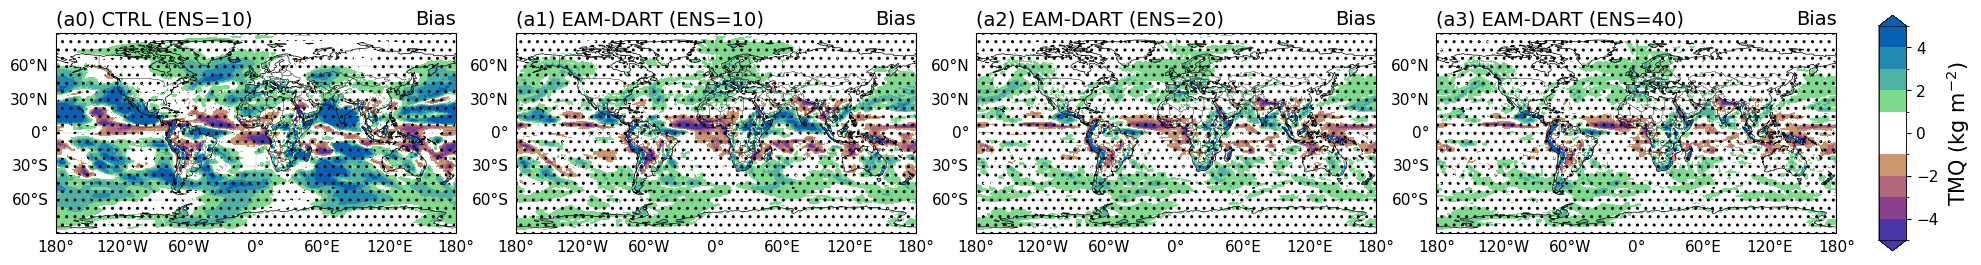

[INFO] Saved: ./TMQ_bias_map_global_atm_monthly_da_201112.pdf in 4.28 s.


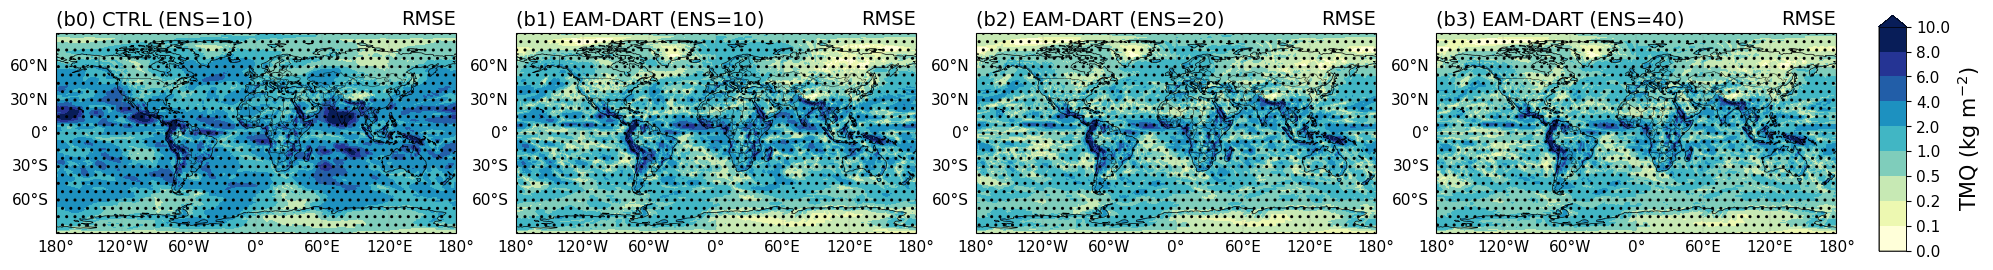

[INFO] Saved: ./TMQ_rmse_map_global_atm_monthly_da_201112.pdf in 4.25 s.


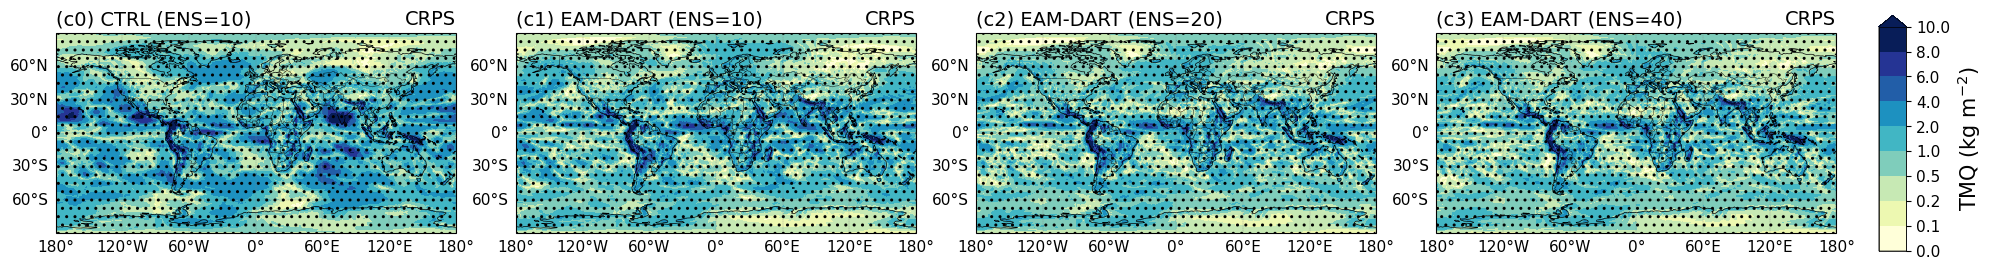

[INFO] Saved: ./TMQ_crps_map_global_atm_monthly_da_201112.pdf in 3.96 s.


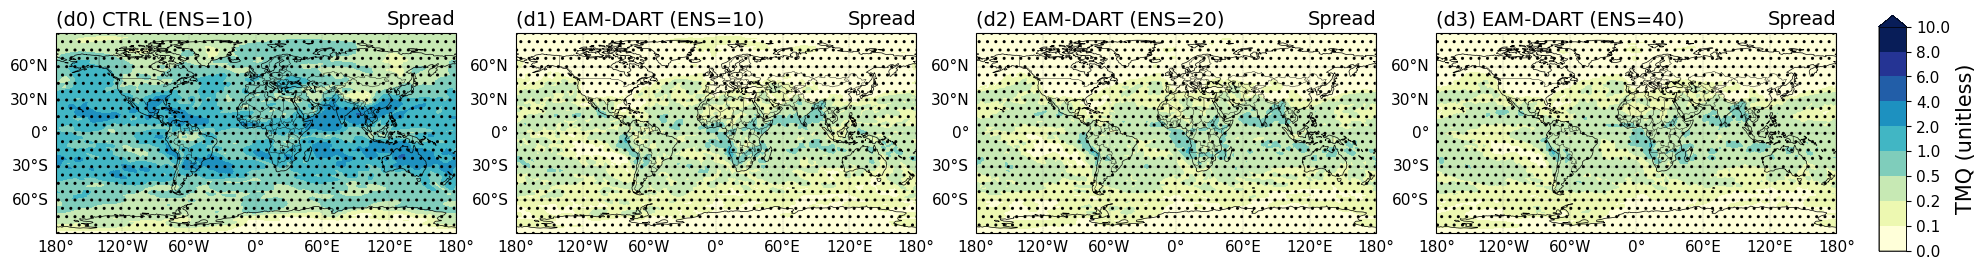

[INFO] Saved: ./TMQ_spread_map_global_atm_monthly_da_201112.pdf in 2.56 s.


In [3]:
if __name__ == "__main__":
    # --- paths ---
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_output/analysis_bias"
    mask_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_output/landmask_1x1.nc"
    fig_path  = "./"
    os.makedirs(fig_path, exist_ok=True)

    freq      = "monthly"
    component = "atm"
    run_seg   = "da"
    regnam    = "global"
    period    = "201112"
    out_tag   = f"{component}_{freq}_{run_seg}_{period}"

    var_dict = {
        #"FLUT": {
        #    "alias":"FLUT", 
        #    "unit":"W m$^{-2}$", 
        #    "ref":"CERES-OAFlux", 
        #    "lev_bias"   : np.linspace(-20,20,11),
        #    "lev_crps"   : [0,1,2,4,6,8,10,12,16,20],
        #    "lev_rmse"   : [0,1,2,4,6,8,10,12,16,20],
        #    "lev_spread" : [0,1,2,4,6,8,10,12,16,20],
        #},
        #"PRECT": {
        #    "alias":"PRECT", 
        #    "unit":"mm day$^{-1}$", 
        #    "ref":"GPCP", 
        #    "lev_bias"   : np.linspace(-5,5,11),
        #    "lev_crps"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_rmse"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_spread" : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #},
        #"PSL": {
        #    "alias":"PSL", 
        #    "unit":"hPa", 
        #    "ref":"ERA5", 
        #    "lev_bias"   : np.linspace(-10,10,11),
        #    "lev_crps"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_rmse"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_spread" : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #},
        #"TREFHT": {
        #    "alias":"TREFHT", 
        #    "unit":"$^o$C", 
        #    "ref":"ERA5", 
        #    "lev_bias"   : np.linspace(-5,5,11),
        #    "lev_crps"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_rmse"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_spread" : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #},
        #"TS": {
        #    "alias":"TS", 
        #    "unit":"$^o$C", 
        #    "ref":"ERA5", 
        #    "lev_bias"   : np.linspace(-5,5,11),
        #    "lev_crps"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_rmse"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #    "lev_spread" : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        #},
        "TMQ": {
            "alias":"TMQ", 
            "unit":"kg m$^{-2}$",
            "ref":"ERA5", 
            "lev_bias"   : np.linspace(-5,5,11),
            "lev_crps"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
            "lev_rmse"   : [0,0.1,0.2,0.5,1,2,4,6,8,10],
            "lev_spread" : [0,0.1,0.2,0.5,1,2,4,6,8,10],
        },
    }

    model_label_map = {
        "CTRL10-S0": "CTRL (ENS=10)",
        "DART10-S0": "EAM-DART (ENS=10)",
        "DART20-S0": "EAM-DART (ENS=20)",
        "DART40-S0": "EAM-DART (ENS=40)",
    }

    file_key = "ensemble_metrics"

    # Use CI hatching only for bias
    diag_vars = [
        ("bias_map",  "bias_map_ci_lower",  "bias_map_ci_upper",   "Bias"),
        ("rmse_map",  "rmse_map_ci_lower",  "rmse_map_ci_upper",   "RMSE"),
        ("crps_map",  "crps_map_ci_lower",  "crps_map_ci_upper",   "CRPS"),
        ("spread_map","spread_map_ci_lower","spread_map_ci_upper", "Spread"),
    ]

    plotter = SpatialMetricPlotter(mask_path)
    # Optional custom colormap:
    # cmap = cc.cm["CET_C9s"]
    cmap = cc.cm["CET_C9s"]

    for var, vinfo in var_dict.items():
        for kk, (metric_key, mask_lower, mask_upper, metric_title) in enumerate(diag_vars):
            try:
                plotter.plot_variable_metric(
                    var=var,
                    vinfo=vinfo,
                    file_key=file_key,
                    metric_key=metric_key,
                    metric_title=metric_title,
                    fig_idx = kk, 
                    model_dict=model_label_map,
                    data_path=data_path,
                    fig_path=fig_path,
                    regnam=regnam,
                    mask_lower_key=mask_lower,
                    mask_upper_key=mask_upper,
                    out_tag=out_tag,
                    cmap=cmap,          # <- now actually used (or keep None)
                    epsilon=0.1 if metric_key == "bias_map" else 0.0
                )
            except Exception as e:
                print(f"[ERROR] Failed {var} {metric_key}: {e}")
